# Quickstart: ECMWF IFS ENS forecast, 46 day, daily, 1.5 degree - dynamical.org Icechunk Zarr
A brief introduction to the ECMWF IFS Ensemble forecast dataset transformed into an analysis-ready, cloud-optimized format by dynamical.org.

Daily forecasts on a 1.5° global grid, with 101 members extending to day 46. ECMWF makes these sub-seasonal forecasts available after a 48-hour delay.

Dataset documentation: https://dynamical.org/catalog/ecmwf-ifs-ens-forecast-46-day-daily-1-5-degree/

Dataset licenced [CC-BY-4.0](https://creativecommons.org/licenses/by/4.0/) and [ECMWF Terms of Use](https://apps.ecmwf.int/datasets/licences/general/)


In [ ]:
# If running locally, follow README.md for simple dependency installation.
# If using Google Colab, run this cell.
!uv pip install dynamical-catalog cartopy

In [2]:
import dynamical_catalog

ds = dynamical_catalog.open("ecmwf-ifs-ens-forecast-46-day-daily-1-5-degree", chunks=None)
ds

<xarray.Dataset> Size: 5TB
Dimensions:                                                   (init_time: 257,
                                                               lead_time: 47,
                                                               ensemble_member: 101,
                                                               latitude: 121,
                                                               longitude: 240)
Coordinates:
  * init_time                                                 (init_time) datetime64[ns] 2kB ...
    ingested_forecast_length                                  (init_time) timedelta64[us] 2kB ...
    expected_forecast_length                                  (init_time) timedelta64[us] 2kB ...
  * lead_time                                                 (lead_time) timedelta64[us] 376B ...
    valid_time                                                (init_time, lead_time) datetime64[ns] 97kB ...
  * ensemble_member                                           (ensemble_member) int16 202B ...
  * latitude                                                  (latitude) float64 968B ...
  * longitude                                                 (longitude) float64 2kB ...
    spatial_ref                                               int64 8B ...
Data variables: (12/35)
    average_convective_available_potential_energy_atmosphere  (init_time, lead_time, ensemble_member, latitude, longitude) float32 142GB ...
    downward_long_wave_radiation_flux_surface                 (init_time, lead_time, ensemble_member, latitude, longitude) float32 142GB ...
    downward_short_wave_radiation_flux_surface                (init_time, lead_time, ensemble_member, latitude, longitude) float32 142GB ...
    eastward_turbulent_surface_stress                         (init_time, lead_time, ensemble_member, latitude, longitude) float32 142GB ...
    average_dew_point_temperature_2m                          (init_time, lead_time, ensemble_member, latitude, longitude) float32 142GB ...
    average_temperature_2m                                    (init_time, lead_time, ensemble_member, latitude, longitude) float32 142GB ...
    ...                                                        ...
    soil_temperature_0_20cm                                   (init_time, lead_time, ensemble_member, latitude, longitude) float32 142GB ...
    soil_temperature_0_100cm                                  (init_time, lead_time, ensemble_member, latitude, longitude) float32 142GB ...
    total_column_water_atmosphere                             (init_time, lead_time, ensemble_member, latitude, longitude) float32 142GB ...
    wind_u_10m                                                (init_time, lead_time, ensemble_member, latitude, longitude) float32 142GB ...
    wind_v_10m                                                (init_time, lead_time, ensemble_member, latitude, longitude) float32 142GB ...
    total_cloud_cover_atmosphere                              (init_time, lead_time, ensemble_member, latitude, longitude) float32 142GB ...
Attributes:
    dataset_id:           ecmwf-ifs-ens-forecast-46-day-daily-1-5-degree
    dataset_version:      0.2.0
    name:                 ECMWF IFS ENS forecast, 46 day, daily, 1.5 degree
    description:          Sub-seasonal-range ensemble weather forecasts from ...
    attribution:          ECMWF IFS ENS sub-seasonal-range forecast data proc...
    license:              CC-BY-4.0
    spatial_domain:       Global
    spatial_resolution:   1.5 degrees (~165km)
    time_domain:          Forecasts initialized 2026-01-01 00:00:00 UTC to Pr...
    time_resolution:      Forecasts initialized every 24 hours
    forecast_domain:      Forecast lead time 0-1104 hours (0-46 days) ahead
    forecast_resolution:  Forecast step 24 hourly

Daily means and rates start at lead time 24 hours; the 0-hour step has no preceding day to summarize.

## How much do individual forecasts differ?

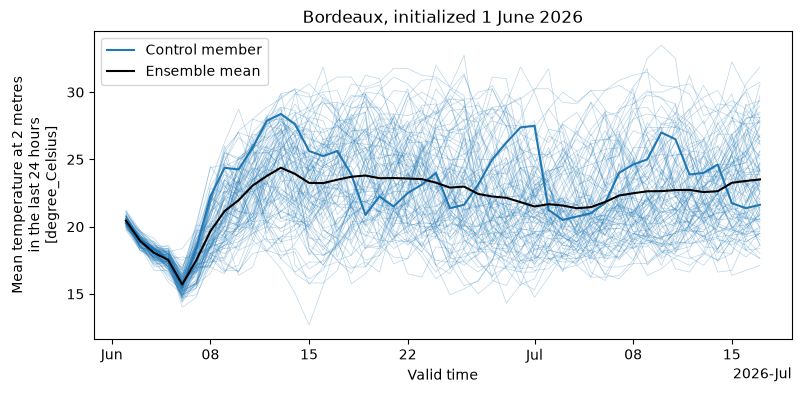

In [3]:
import matplotlib.pyplot as plt

temperature = (
    ds["average_temperature_2m"]
    .sel(init_time="2026-06-01T00", latitude=44.84, longitude=-0.58, method="nearest")
    .sel(lead_time=slice("1d", "46d"))
    .load()
)
temperature.plot(
    x="valid_time", hue="ensemble_member", color="tab:blue",
    linewidth=0.5, alpha=0.3, add_legend=False, size=4, aspect=2.25,
)
ax = plt.gca()
temperature.sel(ensemble_member=0).plot(
    ax=ax, x="valid_time", color="tab:blue", label="Control member",
)
temperature.mean("ensemble_member", keep_attrs=True).plot(
    ax=ax, x="valid_time", color="black", label="Ensemble mean",
)
ax.legend()
ax.set_title("Bordeaux, initialized 1 June 2026");


## How wide was the temperature outlook for Bordeaux?

France experienced a heatwave on 17–30 June 2026.

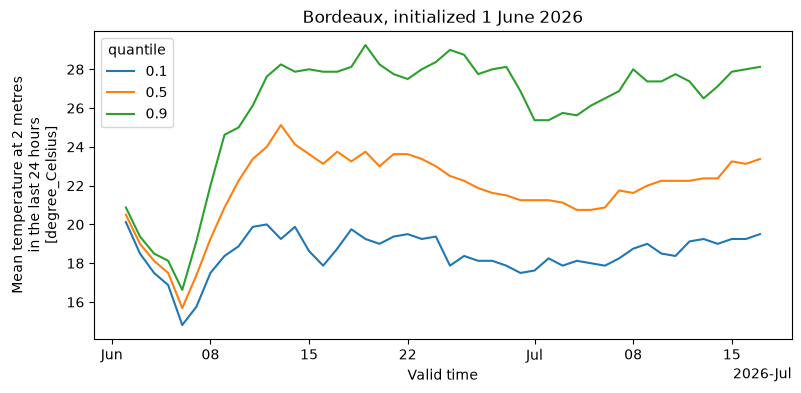

In [4]:
temperature.quantile([0.1, 0.5, 0.9], dim="ensemble_member", keep_attrs=True).plot(
    x="valid_time", hue="quantile", size=4, aspect=2.25,
)
plt.title("Bordeaux, initialized 1 June 2026");

## Where do members disagree about large-scale flow?

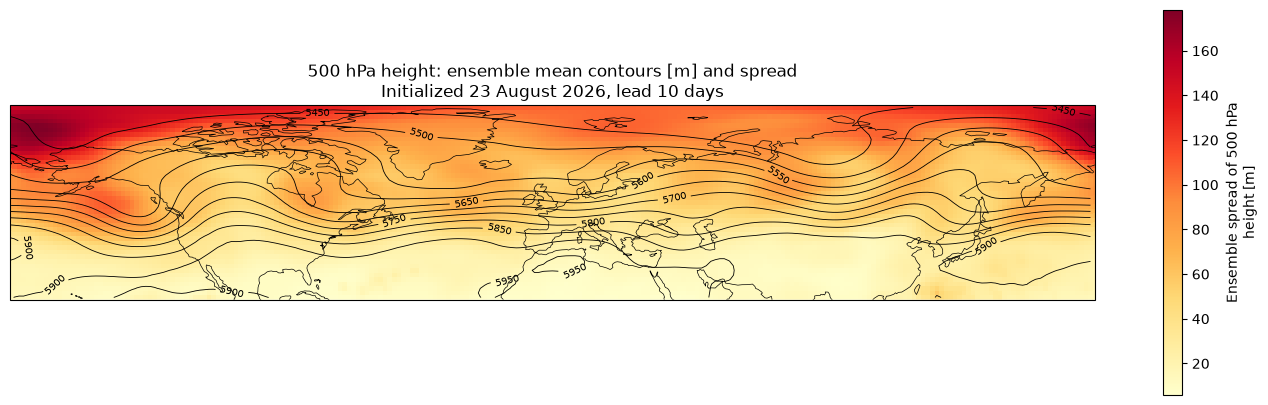

In [5]:
import cartopy.crs as ccrs

ds_pressure = dynamical_catalog.open(
    "ecmwf-ifs-ens-forecast-46-day-daily-1-5-degree", group="pressure_level", chunks=None
)
height_500 = ds_pressure["geopotential_height"].sel(
    init_time="2026-08-23T00", lead_time="10d", pressure_level=500,
    latitude=slice(85, 20),
).load()
spread = height_500.std("ensemble_member", keep_attrs=True)
spread.attrs = {"long_name": "Ensemble spread of 500 hPa height", "units": "m"}

plot = spread.plot(
    subplot_kws={"projection": ccrs.PlateCarree()},
    transform=ccrs.PlateCarree(), cmap="YlOrRd", size=5, aspect=3.5,
)
ax = plot.axes
contours = height_500.mean("ensemble_member", keep_attrs=True).plot.contour(
    ax=ax, transform=ccrs.PlateCarree(), levels=12, colors="black", linewidths=0.6,
)
ax.clabel(contours, inline=True, fontsize=7, fmt="%d")
ax.coastlines(linewidth=0.5)
ax.set_title("500 hPa height: ensemble mean contours [m] and spread\nInitialized 23 August 2026, lead 10 days");

## Open questions

- At which lead times does the ensemble outperform climatology, and how does that depend on region and season?
- How do daily values and weekly means compare when benchmarked against observations?
- Does ensemble spread reliably track forecast error?
